In [2]:
import pandas as pd 
import numpy as np 
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

#load dataset 
sales = pd.read_csv(r'C:\Users\2401030182\Desktop\FDA_Statistical_Datasets\sales_data.csv')
employee = pd.read_csv(r'C:\Users\2401030182\Desktop\FDA_Statistical_Datasets\employee_performance.csv')
survey = pd.read_csv(r'C:\Users\2401030182\Desktop\FDA_Statistical_Datasets\survey_data.csv')
regional = pd.read_csv(r'C:\Users\2401030182\Desktop\FDA_Statistical_Datasets\regional_sales.csv')
student = pd.read_csv(r'C:\Users\2401030182\Desktop\FDA_Statistical_Datasets\student_behavior.csv')


In [4]:
datasets={
    "Sales":sales['Order_Amount'],
    "Regional Sales":regional['Sales'],
    "Student Marks": student['Marks']
}
for name, data in datasets.items():
    print(f"\n{name}")
    print("Mean:", data.mean())
    print("Median:", data.median())
    print("Variance:", data.var())
    print("Std Dev:", data.std())
    
    

#Mean > Median → Right skew (high-value outliers)
#Mean < Median → Left skew


Sales
Mean: 2667.52
Median: 2796.5
Variance: 1888218.3127272727
Std Dev: 1374.124562304041

Regional Sales
Mean: 5364.75
Median: 5207.0
Variance: 7260866.108585859
Std Dev: 2694.5994337908296

Student Marks
Mean: 71.65
Median: 69.0
Variance: 295.32070707070693
Std Dev: 17.184897645045982


In [5]:
variability = {name: data.std() for name, data in datasets.items()}
print(max(variability, key=variability.get))


#High variance → inconsistent performance (risk)
#Low variance → stable operations

Regional Sales


In [6]:
#HYPOTHESIS
t_stat, p_value = stats.ttest_rel(
    employee['Before_Training_Score'],
    employee['After_Training_Score']
)

print("t-statistics:" ,t_stat)
print("p-value:", p_value)

t-statistics: -8.406609742343647
p-value: 1.4035184908309465e-12


In [8]:
#chi square test 

contingency_table=pd.crosstab(
    survey['Gender'],
    survey['Preferred_Product_Category']
)

chi2, p, dof, expected =stats.chi2_contingency(contingency_table)
print("chi square:", chi2)
print("p value:", p)
print("expected frequencies: ", expected)


#assumptions are as follows:
#p < 0.05 → Variables are dependent
#p ≥ 0.05 → Independent


chi square: 1.8425503185224308
p value: 0.39801118970301597
expected frequencies:  [[17.55833333 13.88333333 17.55833333]
 [25.44166667 20.11666667 25.44166667]]


In [12]:
groups = [group['Sales'].values for name, group in regional.groupby('Region')]

f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)



#interpretation 
#p < 0.05 → Significant difference exists

F-statistic: 0.5372191906231476
p-value: 0.6579042865117707


In [16]:
#correlation analysis

pearson_corr= student['Study_Hours'].corr(student['Marks'], method='pearson')
spearman_corr=student['Study_Hours'].corr(student['Marks'],method='spearman')

print("Pearson:", pearson_corr)
print("Spearman:", spearman_corr)


#interpretation: 

#+1 → Strong positive
# 0 → No relation
#-1 → Strong negative

# Difference:

#Pearson → Linear relationship
#Spearman → Monotonic relationship

Pearson: -0.019598328003006815
Spearman: -0.0037116805575387202


In [17]:
#outlier analysis (detecting outliers through IQR Method)

Q1 = sales['Order_Amount'].quantile(0.25)
Q3 = sales['Order_Amount'].quantile(0.75)
IQR = Q3 - Q1

outliers = sales[(sales['Order_Amount'] < Q1 - 1.5*IQR) |
                 (sales['Order_Amount'] > Q3 + 1.5*IQR)]

print("Outliers:\n", outliers)


Outliers:
 Empty DataFrame
Columns: [Customer_ID, City, Order_Amount, Payment_Method]
Index: []


In [18]:
#before vs after

clean_data = sales[(sales['Order_Amount'] >= Q1 - 1.5*IQR) &
                   (sales['Order_Amount'] <= Q3 + 1.5*IQR)]

print("Mean Before:", sales['Order_Amount'].mean())
print("Mean After:", clean_data['Order_Amount'].mean())

Mean Before: 2667.52
Mean After: 2667.52


In [19]:
# 🔹 Part 7: Business Decision Making


# 1. Should training continue?
#  Yes, if p < 0.05 in t-test
# Evidence: Significant improvement in scores

# 2. Which region needs improvement?
#  Region with:
# - Lowest mean sales
# - High variance

# 3. Is product preference dependent on gender?
#  Based on chi-square:
# - p < 0.05 → Yes
# - p ≥ 0.05 → No

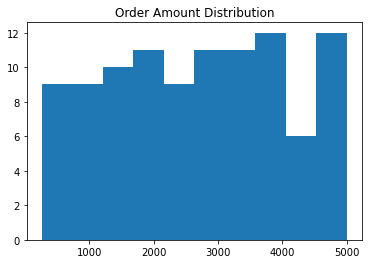

In [20]:
#visualisation 

#histogram
plt.hist(sales['Order_Amount'])
plt.title("Order Amount Distribution")
plt.show()

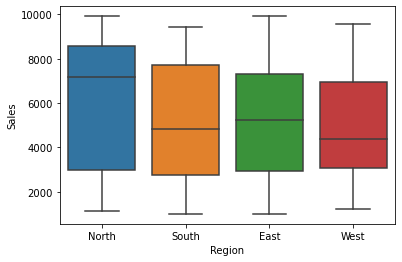

In [21]:
#box plot

sns.boxplot(x='Region', y='Sales', data=regional)
plt.show()

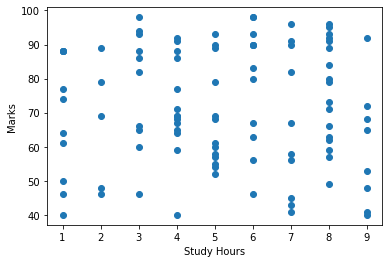

In [22]:
#scatter plot 

plt.scatter(student['Study_Hours'], student['Marks'])
plt.xlabel("Study Hours")
plt.ylabel('Marks')
plt.show()

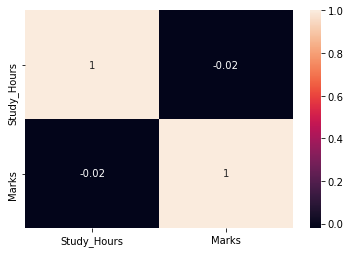

In [23]:
#heatmap 

corr_matrix=student.corr()
sns.heatmap(corr_matrix,annot=True)
plt.show()